In [13]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from Core.dsp_utils import get_features, butter_highpass_filter

In [18]:
import importlib
import sys

# Eliminar el módulo cacheado
if 'Core.dsp_utils' in sys.modules:
    del sys.modules['Core.dsp_utils']
if 'dsp_utils' in sys.modules:
    del sys.modules['dsp_utils']

# Ahora sí importar de nuevo
sys.path.append(os.path.abspath(".."))
from Core.dsp_utils import get_features, butter_highpass_filter

In [19]:
# ── Celda: Paths de los datasets de fine-tuning ──────────────
MESD_CHILD_DIR  = "/Users/Catalina/IBIO/2026-1/PD2/Modelo final/Speech-Emotion-Recognition-with-MFCC-main/Audios 6 clases/Mexican Emotional Speech Database (MESD)"       # ← audios MESD solo niños

In [20]:
import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from scipy.signal import butter, lfilter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.optimizers import Adam

In [21]:
X_mesd, Y_mesd = [], []
emotion_map_mesd = {
    "Anger": "enojo", "Disgust": "disgusto", "Fear": "miedo",
    "Happiness": "felicidad", "Neutral": "neutral", "Sadness": "tristeza"
}

for fname in os.listdir(MESD_CHILD_DIR):
    if not fname.lower().endswith(".wav"): continue
    parts = fname.split("_")
    if len(parts) < 2 or parts[1] not in ["C", "F", "M"]: continue
    
    label = emotion_map_mesd.get(parts[0])
    if label:
        try:
            feats = get_features(os.path.join(MESD_CHILD_DIR, fname))
            for f in feats:
                X_mesd.append(f)
                Y_mesd.append(label)
        except Exception as e:
            print(f"⚠ Error en {fname}: {e}")

print(f"✓ Datos cargados: {len(X_mesd)} muestras")

✓ Datos cargados: 2586 muestras


In [22]:
X_ft = np.array(X_mesd)
Y_ft = np.array(Y_mesd)

# Splits: Train (70%), Val (10%), Test (20%)
X_temp, X_test, Y_temp, Y_test_raw = train_test_split(X_ft, Y_ft, test_size=0.2, stratify=Y_ft, random_state=42)
X_train, X_val, Y_train_raw, Y_val_raw = train_test_split(X_temp, Y_temp, test_size=0.125, stratify=Y_temp, random_state=42)

# Escalador (Scaler)
scaler_final = StandardScaler()
X_train = scaler_final.fit_transform(X_train)
X_val = scaler_final.transform(X_val)
X_test = scaler_final.transform(X_test)

# Reshape para CNN
X_train = np.expand_dims(X_train, axis=2)
X_val = np.expand_dims(X_val, axis=2)
X_test = np.expand_dims(X_test, axis=2)

# Encoder
encoder_final = OneHotEncoder(sparse_output=False)
Y_train = encoder_final.fit_transform(Y_train_raw.reshape(-1, 1))
Y_val = encoder_final.transform(Y_val_raw.reshape(-1, 1))
Y_test = encoder_final.transform(Y_test_raw.reshape(-1, 1))

In [23]:
modelo_ninos = Sequential([
    Conv1D(256, kernel_size=5, strides=1, padding='same', activation='relu', input_shape=(X_train.shape[1], 1)),
    MaxPooling1D(pool_size=5, strides=2, padding='same'),
    Conv1D(256, kernel_size=5, strides=1, padding='same', activation='relu'),
    MaxPooling1D(pool_size=5, strides=2, padding='same'),
    Conv1D(128, kernel_size=5, strides=1, padding='same', activation='relu'),
    MaxPooling1D(pool_size=5, strides=2, padding='same'),
    Dropout(0.2),
    Conv1D(64, kernel_size=5, strides=1, padding='same', activation='relu'),
    MaxPooling1D(pool_size=5, strides=2, padding='same'),
    Flatten(),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(6, activation='softmax')
])

modelo_ninos.compile(optimizer=Adam(learning_rate=1e-3), loss='categorical_crossentropy', metrics=['accuracy'])

# Entrenamiento con Early Stopping para encontrar la época óptima
history = modelo_ninos.fit(X_train, Y_train, batch_size=16, epochs=100, 
                           validation_data=(X_val, Y_val), 
                           callbacks=[EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)])

# Entrenar modelo final con Train+Val usando la mejor época
best_epoch = np.argmax(history.history['val_accuracy']) + 1
X_trainval = np.concatenate([X_train, X_val])
Y_trainval = np.concatenate([Y_train, Y_val])

modelo_ninos.fit(X_trainval, Y_trainval, batch_size=16, epochs=best_epoch, verbose=1)

/opt/anaconda3/envs/audio_ml/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.2593 - loss: 1.7343 - val_accuracy: 0.3475 - val_loss: 1.6192
Epoch 2/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.3466 - loss: 1.6143 - val_accuracy: 0.3668 - val_loss: 1.4952
Epoch 3/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.3947 - loss: 1.5058 - val_accuracy: 0.4208 - val_loss: 1.4605
Epoch 4/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.4433 - loss: 1.4039 - val_accuracy: 0.4903 - val_loss: 1.3356
Epoch 5/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.4782 - loss: 1.3399 - val_accuracy: 0.4749 - val_loss: 1.3498
Epoch 6/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.4760 - loss: 1.2998 - val_accuracy: 0.4942 - val_loss: 1.2840
Epoch 7/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.5445 - loss: 1.1953 - val_accuracy: 0.5560 - val_loss: 1.1519
Epoch 8/100
114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.5478 - loss: 1.1486 - 

In [24]:
# Aseguramos que los nombres coincidan con los usados arriba
# modelo_ninos, scaler_final, encoder_final
modelo_ninos.save("../models/vocalink_ninos.keras") 
joblib.dump(scaler_final, "../models/scaler.pkl") 
joblib.dump(encoder_final, "../models/encoder.pkl")

print("✓ Modelo de niños y herramientas guardados exitosamente en /models")

✓ Modelo de niños y herramientas guardados exitosamente en /models


11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
=== CLASSIFICATION REPORT FINAL (Vocalink - MESD) ===
              precision    recall  f1-score   support

    disgusto       0.86      0.75      0.80        76
       enojo       0.63      0.66      0.64        58
   felicidad       0.72      0.66      0.69        64
       miedo       0.64      0.60      0.62        48
     neutral       0.31      0.46      0.37        24
    tristeza       0.70      0.76      0.73        62

    accuracy                           0.67       332
   macro avg       0.65      0.65      0.64       332
weighted avg       0.69      0.67      0.68       332



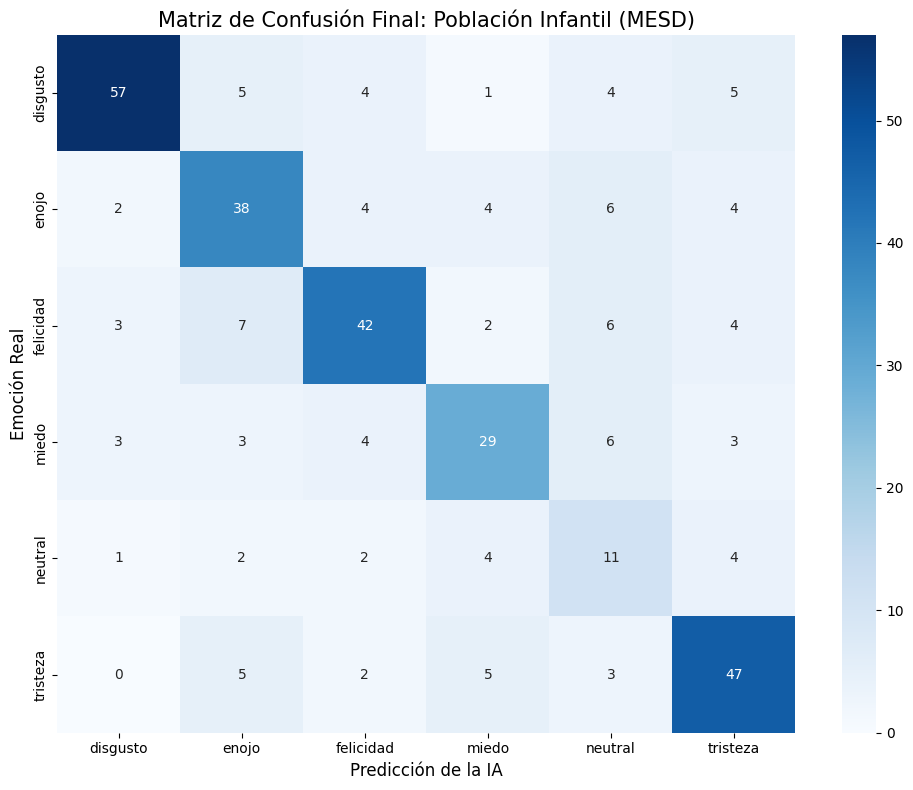

In [17]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Obtener predicciones sobre el conjunto de test
y_pred_prob = modelo_ninos.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(Y_test, axis=1)

# 2. Obtener nombres de las clases (emociones)
clases = encoder_final.categories_[0]

# 3. GENERAR EL CLASSIFICATION REPORT (El del 0.68)
report = classification_report(y_true, y_pred, target_names=clases)
print("=== CLASSIFICATION REPORT FINAL (Vocalink - MESD) ===")
print(report)

# 4. GENERAR LA MATRIZ DE CONFUSIÓN AZUL
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=clases, yticklabels=clases)

plt.title('Matriz de Confusión Final: Población Infantil (MESD)', fontsize=15)
plt.xlabel('Predicción de la IA', fontsize=12)
plt.ylabel('Emoción Real', fontsize=12)
plt.tight_layout()

plt.savefig("matriz_confusion_final.png", dpi=300)
plt.show()